Saved time.pdf


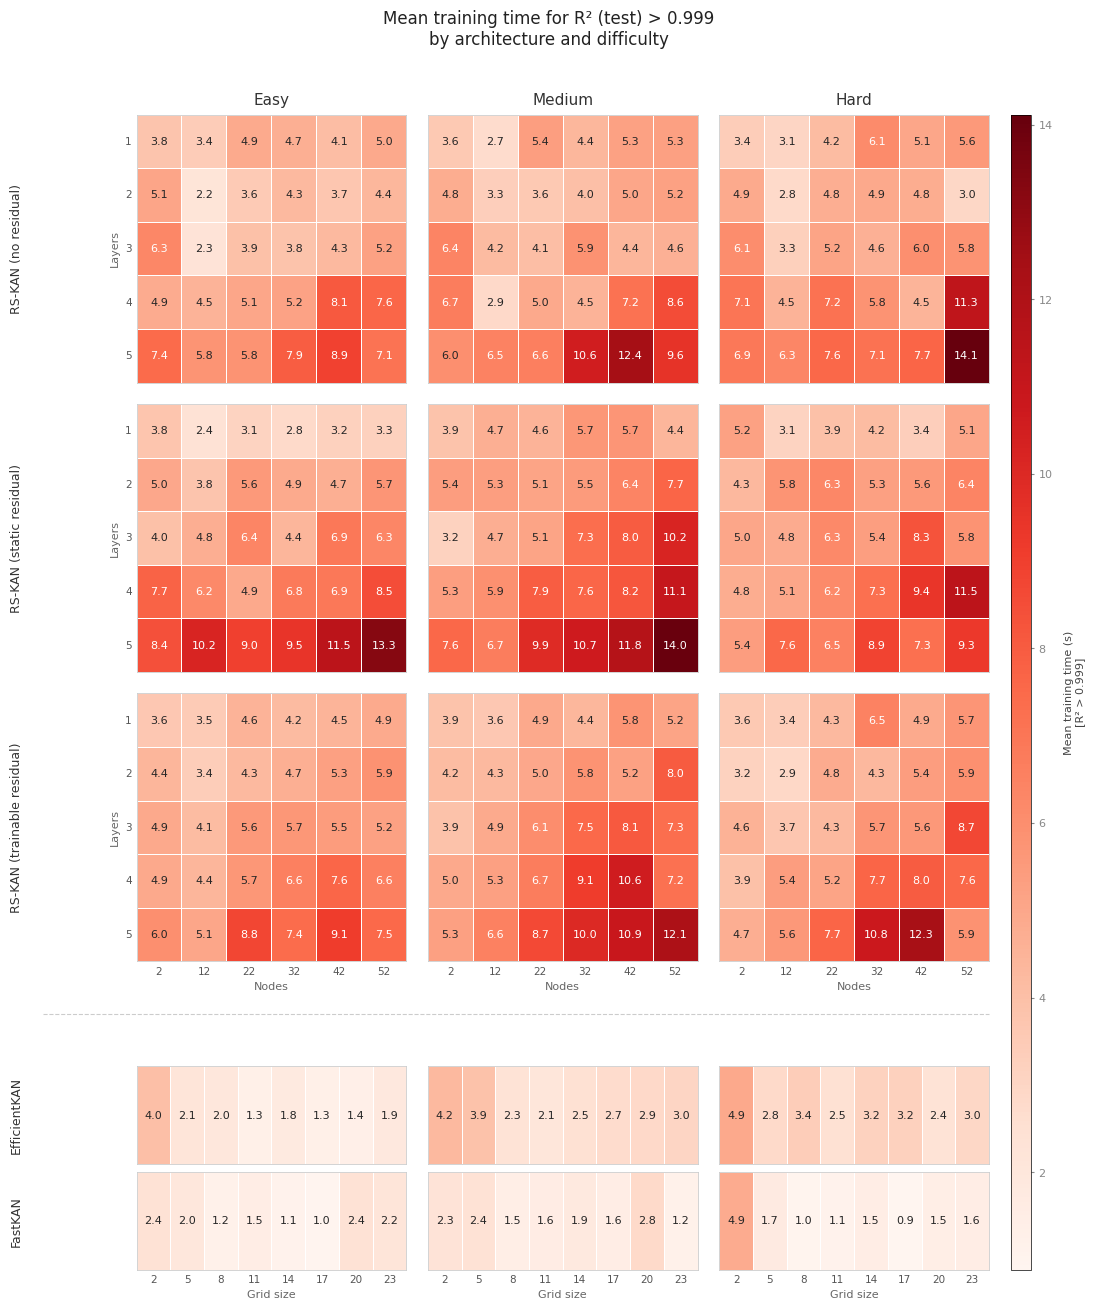

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

THRESHOLD = 0.999
DIFFS     = ["Easy", "Medium", "Hard"]

# ── Load data ─────────────────────────────────────────────────────────────────
heatmap_files = {
    "RS-KAN\n(no residual)":        "./parameterTests/MLPKAN_nores.csv",
    "RS-KAN\n(static residual)":           "./parameterTests/MLPKAN_res.csv",
    "RS-KAN\n(trainable residual)": "./parameterTests/MLPKAN_restrainable.csv",
}
strip_files = {
    "EfficientKAN": "./parameterTests/EfficientKAN22.csv",
    "FastKAN":      "./parameterTests/FastKAN2.csv",
}

heatmap_dfs   = {n: pd.read_csv(p) for n, p in heatmap_files.items()}
strip_dfs     = {n: pd.read_csv(p) for n, p in strip_files.items()}
HEATMAP_ARCHS = list(heatmap_files.keys())
STRIP_ARCHS   = list(strip_files.keys())
NODES         = sorted(heatmap_dfs[HEATMAP_ARCHS[0]]["Nodes"].unique())
LAYERS        = sorted(heatmap_dfs[HEATMAP_ARCHS[0]]["Layers"].unique())
GRID_SIZES    = sorted(strip_dfs[STRIP_ARCHS[0]]["Grid Size"].unique())

# ── Aggregation: mean time of qualifying runs ─────────────────────────────────
def make_pivot(df, difficulty):
    sub = df[(df["Level"] == difficulty) & (df["R2 Score (Test)"] > THRESHOLD)].copy()
    return (
        sub.groupby(["Layers", "Nodes"])["time"]
        .mean().unstack("Nodes")
        .reindex(index=LAYERS, columns=NODES)
    )

def make_strip(df, difficulty):
    sub = df[(df["Level"] == difficulty) & (df["R2 Score (Test)"] > THRESHOLD)].copy()
    series = sub.groupby("Grid Size")["time"].mean().reindex(GRID_SIZES)
    return pd.DataFrame([series.values], columns=GRID_SIZES, index=[""])

pivots = {a: {d: make_pivot(heatmap_dfs[a], d) for d in DIFFS} for a in HEATMAP_ARCHS}
strips = {a: {d: make_strip(strip_dfs[a],   d) for d in DIFFS} for a in STRIP_ARCHS}

# ── Shared colour range (NaN cells excluded) ──────────────────────────────────
all_vals = np.concatenate([
    p.values.ravel() for ad in pivots.values() for p in ad.values()
] + [
    s.values.ravel() for ad in strips.values() for s in ad.values()
])
all_vals = all_vals[~np.isnan(all_vals)]
vmin, vmax = all_vals.min(), all_vals.max()

# ── Layout ────────────────────────────────────────────────────────────────────
NCOLS = len(DIFFS); N_HEAT = len(HEATMAP_ARCHS); N_STRP = len(STRIP_ARCHS)
NROWS = N_HEAT + N_STRP; STRIP_H_RATIO = 1.8

FIG_W, FIG_H = 11, 15
fig = plt.figure(figsize=(FIG_W, FIG_H))
outer_gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.20,
    height_ratios=[N_HEAT * len(LAYERS), N_STRP * STRIP_H_RATIO])
heat_gs = gridspec.GridSpecFromSubplotSpec(N_HEAT, NCOLS,
    subplot_spec=outer_gs[0], hspace=0.08, wspace=0.08,
    height_ratios=[len(LAYERS)] * N_HEAT)
strp_gs = gridspec.GridSpecFromSubplotSpec(N_STRP, NCOLS,
    subplot_spec=outer_gs[1], hspace=0.08, wspace=0.08,
    height_ratios=[STRIP_H_RATIO] * N_STRP)

cmap = sns.color_palette("Reds", as_cmap=True)
nan_color = "#e8e8e8"
axes = np.empty((NROWS, NCOLS), dtype=object)

def draw_heatmap(ax, data, ri, ci, is_strip=False):
    # Build a mask for NaN cells
    mask = data.isna()
    # Fill NaN with 0 for rendering, then overlay grey
    data_filled = data.fillna(0)

    sns.heatmap(data_filled, ax=ax, mask=mask,
        cmap=cmap, vmin=vmin, vmax=vmax,
        annot=True, fmt=".1f", annot_kws={"size": 8},
        linewidths=0.4, linecolor="white",
        cbar=False, xticklabels=True, yticklabels=not is_strip)

    # Grey out masked cells and annotate with "—"
    if mask.values.any():
        for r in range(mask.shape[0]):
            for c in range(mask.shape[1]):
                if mask.iloc[r, c]:
                    ax.add_patch(plt.Rectangle((c, r), 1, 1,
                        color=nan_color, zorder=2))
                    ax.text(c + 0.5, r + 0.5, "—",
                        ha="center", va="center",
                        fontsize=8, color="#aaaaaa", zorder=3)

    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_linewidth(0.6); sp.set_edgecolor("#cccccc")

# ── 2-D heatmap rows ─────────────────────────────────────────────────────────
for ri, arch in enumerate(HEATMAP_ARCHS):
    for ci, diff in enumerate(DIFFS):
        ax = fig.add_subplot(heat_gs[ri, ci])
        axes[ri, ci] = ax
        draw_heatmap(ax, pivots[arch][diff], ri, ci)

        if ri == 0:
            ax.set_title(diff, fontsize=11, fontweight="medium", pad=7, color="#333333")
        if ri == N_HEAT - 1:
            ax.set_xlabel("Nodes", fontsize=8, labelpad=4, color="#666666")
            ax.set_xticklabels([str(n) for n in NODES], fontsize=7.5, rotation=0, color="#555555")
        else:
            ax.set_xlabel(""); ax.set_xticklabels([]); ax.tick_params(bottom=False)
        if ci == 0:
            ax.set_ylabel("Layers", fontsize=8, labelpad=4, color="#666666")
            ax.set_yticklabels([str(l) for l in LAYERS], fontsize=7.5, rotation=0, color="#555555")
        else:
            ax.set_ylabel(""); ax.set_yticklabels([]); ax.tick_params(left=False)
        ax.tick_params(length=0)

# ── Strip rows ────────────────────────────────────────────────────────────────
for si, arch in enumerate(STRIP_ARCHS):
    ri = N_HEAT + si
    for ci, diff in enumerate(DIFFS):
        ax = fig.add_subplot(strp_gs[si, ci])
        axes[ri, ci] = ax
        draw_heatmap(ax, strips[arch][diff], ri, ci, is_strip=True)

        if si == N_STRP - 1:
            ax.set_xlabel("Grid size", fontsize=8, labelpad=4, color="#666666")
            ax.set_xticklabels([str(g) for g in GRID_SIZES], fontsize=7.5, rotation=0, color="#555555")
        else:
            ax.set_xlabel(""); ax.set_xticklabels([]); ax.tick_params(bottom=False)
        ax.set_ylabel(""); ax.tick_params(length=0)

# ── Architecture labels ───────────────────────────────────────────────────────
for ri, arch in enumerate(HEATMAP_ARCHS + STRIP_ARCHS):
    pos = axes[ri, 0].get_position()
    fig.text(0.01, (pos.y0 + pos.y1) / 2, arch.replace("\n", " "),
        va="center", ha="left", rotation=90,
        fontsize=9, fontweight="medium", color="#333333")

# ── Divider ───────────────────────────────────────────────────────────────────
p_lh = axes[N_HEAT - 1, 0].get_position()
p_fs = axes[N_HEAT, 0].get_position()
y_div = (p_lh.y0 + p_fs.y1) / 2
fig.add_artist(plt.Line2D([0.04, 0.9], [y_div, y_div],
    transform=fig.transFigure, color="#cccccc", linewidth=0.8, linestyle="--"))

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
p_top = axes[0, NCOLS - 1].get_position()
p_bot = axes[NROWS - 1, NCOLS - 1].get_position()
cbar_ax = fig.add_axes([0.92, p_bot.y0, 0.018, p_top.y1 - p_bot.y0])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(f"Mean training time (s)\n[R² > {THRESHOLD}]",
    fontsize=8, color="#444444", labelpad=8)
cbar.ax.tick_params(labelsize=8, colors="#888888", length=2)
cbar.outline.set_linewidth(0.5)

fig.suptitle(
    f"Mean training time for R² (test) > {THRESHOLD}\nby architecture and difficulty",
    fontsize=12, fontweight="medium", color="#222222", y=0.95)

# plt.savefig("./parameterTests/time.pdf", bbox_inches="tight", facecolor="white")
print("Saved time.pdf")